In [1]:
import pandas as pd
import numpy as np

import geopandas as gpd
from shapely.geometry import Point, LineString
import skmob

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mpl_chord_diagram import chord_diagram
from matplotlib.patches import Patch
import seaborn as sns

In [2]:
# Import movement data
data_path = '../data/movement.csv'

df = pd.read_csv(data_path)
df.head(2)

,licencePlate,car_type,vehicleTypeId,start_move_time,end_move_time,start_lat,start_lon,end_lat,end_lon,start_zip,end_zip,start_area_name,end_area_name,move_duration
0,bn32098,car,2,7/22/2025 9:13,7/22/2025 9:17,55.658398,12.514628,55.658348,12.515684,2500,2500,Valby,Valby,0 days 00:04:00
1,bn32098,car,2,7/22/2025 9:19,7/22/2025 9:23,55.658348,12.515684,55.659286,12.519309,2500,1805,Valby,Frederiksberg C,0 days 00:04:00


In [3]:
# Import movement data
data_path = '../data/movement.csv'

df = pd.read_csv(data_path)
df.head(2)

,licencePlate,car_type,vehicleTypeId,start_move_time,end_move_time,start_lat,start_lon,end_lat,end_lon,start_zip,end_zip,start_area_name,end_area_name,move_duration
0,bn32098,car,2,7/22/2025 9:13,7/22/2025 9:17,55.658398,12.514628,55.658348,12.515684,2500,2500,Valby,Valby,0 days 00:04:00
1,bn32098,car,2,7/22/2025 9:19,7/22/2025 9:23,55.658348,12.515684,55.659286,12.519309,2500,1805,Valby,Frederiksberg C,0 days 00:04:00


In [4]:
df.columns

Index(['licencePlate', 'car_type', 'vehicleTypeId', 'start_move_time',
       'end_move_time', 'start_lat', 'start_lon', 'end_lat', 'end_lon',
       'start_zip', 'end_zip', 'start_area_name', 'end_area_name',
       'move_duration'],
      dtype='object')

#### Inspecting missing values

In [5]:
# How many -1 in zip codes?
print("start_zip == -1:", (df['start_zip'] == -1).sum())
print("end_zip == -1:", (df['end_zip'] == -1).sum())

# What area names correspond to -1 zip codes?
print("\nArea names where start_zip == -1:")
print(df[df['start_zip'] == -1]['start_area_name'].value_counts())

print("\nArea names where end_zip == -1:")
print(df[df['end_zip'] == -1]['end_area_name'].value_counts())

start_zip == -1: 131
end_zip == -1: 134

Area names where start_zip == -1:
NOT_ANNOTATED    131
Name: start_area_name, dtype: int64

Area names where end_zip == -1:
NOT_ANNOTATED    134
Name: end_area_name, dtype: int64


In [6]:
df = df[df['start_zip'] != -1]
df = df[df['end_zip'] != -1]

# Verify
print("Remaining trips:", len(df))

Remaining trips: 469546


In [7]:
df = df[df['start_area_name'] != 'NOT_ANNOTATED']
df = df[df['end_area_name'] != 'NOT_ANNOTATED']

In [8]:
pd.concat([df['start_area_name'], df['end_area_name']]).unique()

array(['Valby', 'Frederiksberg C', 'Kobenhavn SV', 'Kastrup',
       'Kobenhavn S', 'Kobenhavn V', 'Kobenhavn N', 'Kobenhavn K',
       'Gentofte', 'Kobenhavn O', 'Charlottelund', 'Kgs. Lyngby',
       'Hellerup', 'Kobenhavn NV', 'Soborg', 'Bagsvaerd', 'Rodovre',
       'Herlev', 'Nordhavn', 'Hvidovre', 'Glostrup', 'Bronshoj',
       'Skovlunde', 'Klampenborg', 'Vanlose', 'Dyssegoord', 'Taastrup',
       'Virum', 'Albertslund', 'Ballerup'], dtype=object)

#### Build tessellation for flow

In [9]:
# OD matrix
ods = df[['start_area_name', 'end_area_name']].copy()
ods['flow'] = 1
flows = ods.groupby(['start_area_name', 'end_area_name']).flow.count().reset_index()

In [10]:
# Tessellation
tess_start = df[['start_area_name', 'start_lat', 'start_lon']].rename(columns={
    'start_area_name': 'tile_ID', 'start_lat': 'latitude', 'start_lon': 'longitude'
})
tess_end = df[['end_area_name', 'end_lat', 'end_lon']].rename(columns={
    'end_area_name': 'tile_ID', 'end_lat': 'latitude', 'end_lon': 'longitude'
})
tessellation = (
    pd.concat([tess_start, tess_end])
    .groupby('tile_ID')[['latitude', 'longitude']]
    .mean()
    .reset_index()
)

In [11]:
tessellation = (
    pd.concat([tess_start, tess_end])
    .groupby('tile_ID')[['latitude', 'longitude']]
    .mean()
    .reset_index()
)

In [12]:
tess = gpd.GeoDataFrame(
    tessellation,
    geometry=gpd.points_from_xy(tessellation.longitude, tessellation.latitude),
    crs='EPSG:4326'
)

In [13]:
fdf = skmob.FlowDataFrame(
    flows,
    origin='start_area_name',
    destination='end_area_name',
    flow='flow',
    tessellation=tess,
    tile_id='tile_ID'
)

fdf.head()

,origin,destination,flow
0,Albertslund,Albertslund,1
1,Albertslund,Bagsvaerd,1
2,Albertslund,Bronshoj,6
3,Albertslund,Frederiksberg C,3
4,Albertslund,Glostrup,7


#### Plot tessellation

In [14]:
fdf.tessellation.head()

,tile_ID,latitude,longitude,geometry
0,Albertslund,55.670728,12.389820,POINT (12.38982 55.67073)
1,Bagsvaerd,55.757390,12.455336,POINT (12.45534 55.75739)
2,Ballerup,55.729227,12.359258,POINT (12.35926 55.72923)
3,Bronshoj,55.707218,12.488342,POINT (12.48834 55.70722)
4,Charlottelund,55.758048,12.573003,POINT (12.57300 55.75805)


In [15]:
# Visualise tesselation points
m1 = fdf.plot_tessellation(popup_features=['tile_ID'], zoom=10, tiles="cartodbpositron")
m1.save("../artifacts/tessellation_map.html")

In [16]:
m2 = fdf.plot_tessellation(popup_features=['tile_ID'], zoom=10, tiles="cartodbpositron")
fdf.plot_flows(
    min_flow=50, 
    map_f=m2,
    flow_weight=1
    )

m2.save("../artifacts/map_flow.html")

### Time-of-the-day Analysis

### Chord diagram

In [17]:
# pip install holoviews bokeh plotly chord mpl-chord-diagram

In [18]:
time_slices = {
    'Morning (6-10)': (6, 10),
    'Midday (10-15)': (10, 15),
    'Afternoon (15-19)': (15, 19),
    'Night (19-6)': (19, 6)
}

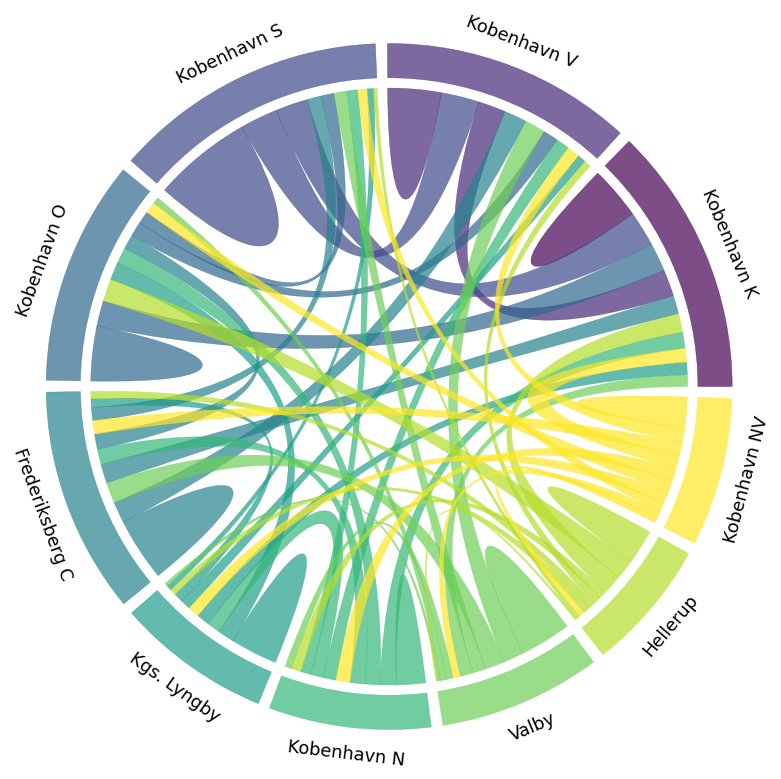

In [19]:
N = 10
top_areas = (
    fdf.groupby('origin')['flow'].sum() + fdf.groupby('destination')['flow'].sum()
).sort_values(ascending=False).head(N).index.tolist()

chord_data = fdf[
    fdf['origin'].isin(top_areas) & 
    fdf['destination'].isin(top_areas)
][['origin', 'destination', 'flow']].copy()

area_idx = {area: i for i, area in enumerate(top_areas)}

# Build matrix
matrix = np.zeros((N, N))
for _, row in chord_data.iterrows():
    i = area_idx[row['origin']]
    j = area_idx[row['destination']]
    matrix[i][j] = row['flow']

fig, ax = plt.subplots(figsize=(8, 8))
chord_diagram(matrix, top_areas, ax=ax)
plt.savefig("../artifacts/chord_diagram.png", dpi=150, bbox_inches='tight')
plt.show()

## The 5 Finger Plan - Flows

### Manually map the different area names to corresponding finger/corridor

From Wikipedia https://en.wikipedia.org/wiki/Finger_Plan

In [20]:
all_areas = pd.concat([df['start_area_name'], df['end_area_name']]).unique()
print('Total number of areas: ', len(all_areas))
all_areas

Total number of areas:  30


array(['Valby', 'Frederiksberg C', 'Kobenhavn SV', 'Kastrup',
       'Kobenhavn S', 'Kobenhavn V', 'Kobenhavn N', 'Kobenhavn K',
       'Gentofte', 'Kobenhavn O', 'Charlottelund', 'Kgs. Lyngby',
       'Hellerup', 'Kobenhavn NV', 'Soborg', 'Bagsvaerd', 'Rodovre',
       'Herlev', 'Nordhavn', 'Hvidovre', 'Glostrup', 'Bronshoj',
       'Skovlunde', 'Klampenborg', 'Vanlose', 'Dyssegoord', 'Taastrup',
       'Virum', 'Albertslund', 'Ballerup'], dtype=object)

In [21]:
finger_map = {
    # Palm: Copenhagen 
    'Kobenhavn K':     'Copenhagen',
    'Kobenhavn N':     'Copenhagen',
    'Kobenhavn NV':    'Copenhagen', 
    'Kobenhavn O':     'Copenhagen',
    'Kobenhavn S':     'Copenhagen',
    'Kobenhavn SV':    'Copenhagen',
    'Kobenhavn V':     'Copenhagen',
    'Frederiksberg C': 'Copenhagen',
    'Valby':           'Copenhagen',
    'Nordhavn':        'Copenhagen',
    'Bronshoj':        'Copenhagen',
    'Vanlose':         'Copenhagen',

    # Little finger
    'Klampenborg':     'F1 Helsingør',
    'Charlottelund':   'F1 Helsingør',
    'Hellerup':        'F1 Helsingør',
    'Gentofte':        'F1 Helsingør',
    'Dyssegoord':      'F1 Helsingør',
    #'Kgs. Lyngby':    'F1 Hillerød', ?? 
    #'Virum':          'F2 Hillerød', ?? 
 

    # Ring finger
    'Kgs. Lyngby':     'F2 Hillerød',
    'Virum':           'F2 Hillerød',
    'Bagsvaerd':       'F2 Hillerød',
    'Soborg':          'F2 Hillerød',

    # Middle finger
    'Herlev':          'F3 Frederikssund',
    'Skovlunde':       'F3 Frederikssund',
    'Ballerup':        'F3 Frederikssund',

    # Index finger
    'Glostrup':        'F4 Roskilde',
    'Albertslund':     'F4 Roskilde',
    'Taastrup':        'F4 Roskilde',
    'Rodovre':         'F4 Roskilde',

    # Thumb
    'Hvidovre':        'F5 Køge',

    # The contemporary 6th finger 
    'Kastrup':         'F6 Amager',
}

In [22]:
# Apply mapping

df['finger_start'] = df['start_area_name'].map(finger_map)
df['finger_end']   = df['end_area_name'].map(finger_map)

### Flows grouped by finger

In [23]:
flows_fingers = (
    df.groupby(['finger_start', 'finger_end'])
    .size()
    .reset_index(name='flow')
)

print(flows_fingers.sort_values('flow', ascending=False).head(2))

  finger_start    finger_end    flow
0   Copenhagen    Copenhagen  197957
1   Copenhagen  F1 Helsingør   29250


In [24]:
# OD matrix

fingers = list(finger_map.values())
fingers = list(dict.fromkeys(fingers)) 

finger_idx = {f: i for i, f in enumerate(fingers)}
N = len(fingers)

matrix = np.zeros((N, N))
for _, row in flows_fingers.iterrows():
    i = finger_idx[row['finger_start']]
    j = finger_idx[row['finger_end']]
    matrix[i][j] = row['flow']

##### Chore diagram

In [ ]:
# Formatting

finger_colors = {
    'Copenhagen':    '#808080',
    'F1 Helsingør':  '#4e79a7',
    'F2 Hillerød':   '#f28e2b',
    'F3 Frederikssund': '#59a14f',
    'F4 Roskilde':   '#e15759',
    'F5 Køge':       '#b07aa1',
    'F6 Amager':     '#edc948',
}

finger_colors_list = list(finger_colors.values())

# Legend
legend_elements = [
    Patch(facecolor='#808080', label='CPH — Copenhagen (Palm)'),
    Patch(facecolor='#4e79a7', label='F1 — Helsingør finger (NE coastal)'),
    Patch(facecolor='#f28e2b', label='F2 — Hillerød finger (North)'),
    Patch(facecolor='#59a14f', label='F3 — Frederikssund finger (NW)'),
    Patch(facecolor='#e15759', label='F4 — Roskilde finger (West)'),
    Patch(facecolor='#b07aa1', label='F5 — Køge finger (South)'),
    Patch(facecolor='#edc948', label='F6 — Amager (6th finger)'),
]

labels = ['CPH', 'F1',  'F2',   'F3',  'F4',  'F5',  'F6']


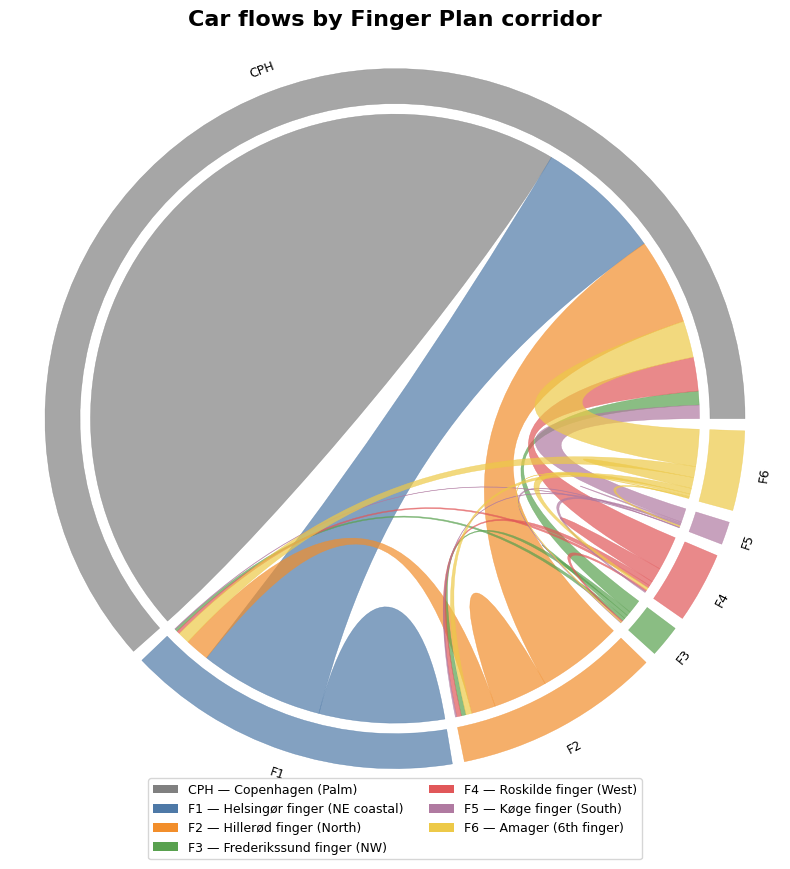

In [26]:
fig, ax = plt.subplots(figsize=(8, 8))
chord_diagram(matrix, labels, ax=ax, fontsize=9, colors=finger_colors_list)
ax.legend(handles=legend_elements, loc='lower center',
          bbox_to_anchor=(0.5, -0.08), fontsize=9,
          framealpha=0.8, ncol=2)
plt.title('Car flows by Finger Plan corridor', fontsize=16, fontweight='bold')
plt.savefig("../artifacts/chord_fingers.png", dpi=150, bbox_inches='tight')
plt.subplots_adjust(bottom=0)
plt.show()

#### More focus on suburban areas 

In [27]:
# Flow suburbs

legend_elements_suburban = [e for e in legend_elements if 'CPH' not in e.get_label()]

flows_no_cph = (
    df[
        (df['finger_start'] != 'Copenhagen') &
        (df['finger_end']   != 'Copenhagen')
    ]
    .groupby(['start_area_name', 'end_area_name'])
    .size()
    .reset_index(name='flow')
)

In [28]:

suburban_areas = [area for area, finger in finger_map.items()
                  if finger != 'Copenhagen']

area_idx = {area: i for i, area in enumerate(suburban_areas)}
N = len(suburban_areas)

In [29]:
# OD matrix
matrix_no_cph = np.zeros((N, N))
for _, row in flows_no_cph.iterrows():
    if row['start_area_name'] in area_idx and row['end_area_name'] in area_idx:
        i = area_idx[row['start_area_name']]
        j = area_idx[row['end_area_name']]
        matrix_no_cph[i][j] = row['flow']

colors_suburban = [finger_colors[finger_map[a]] for a in suburban_areas]

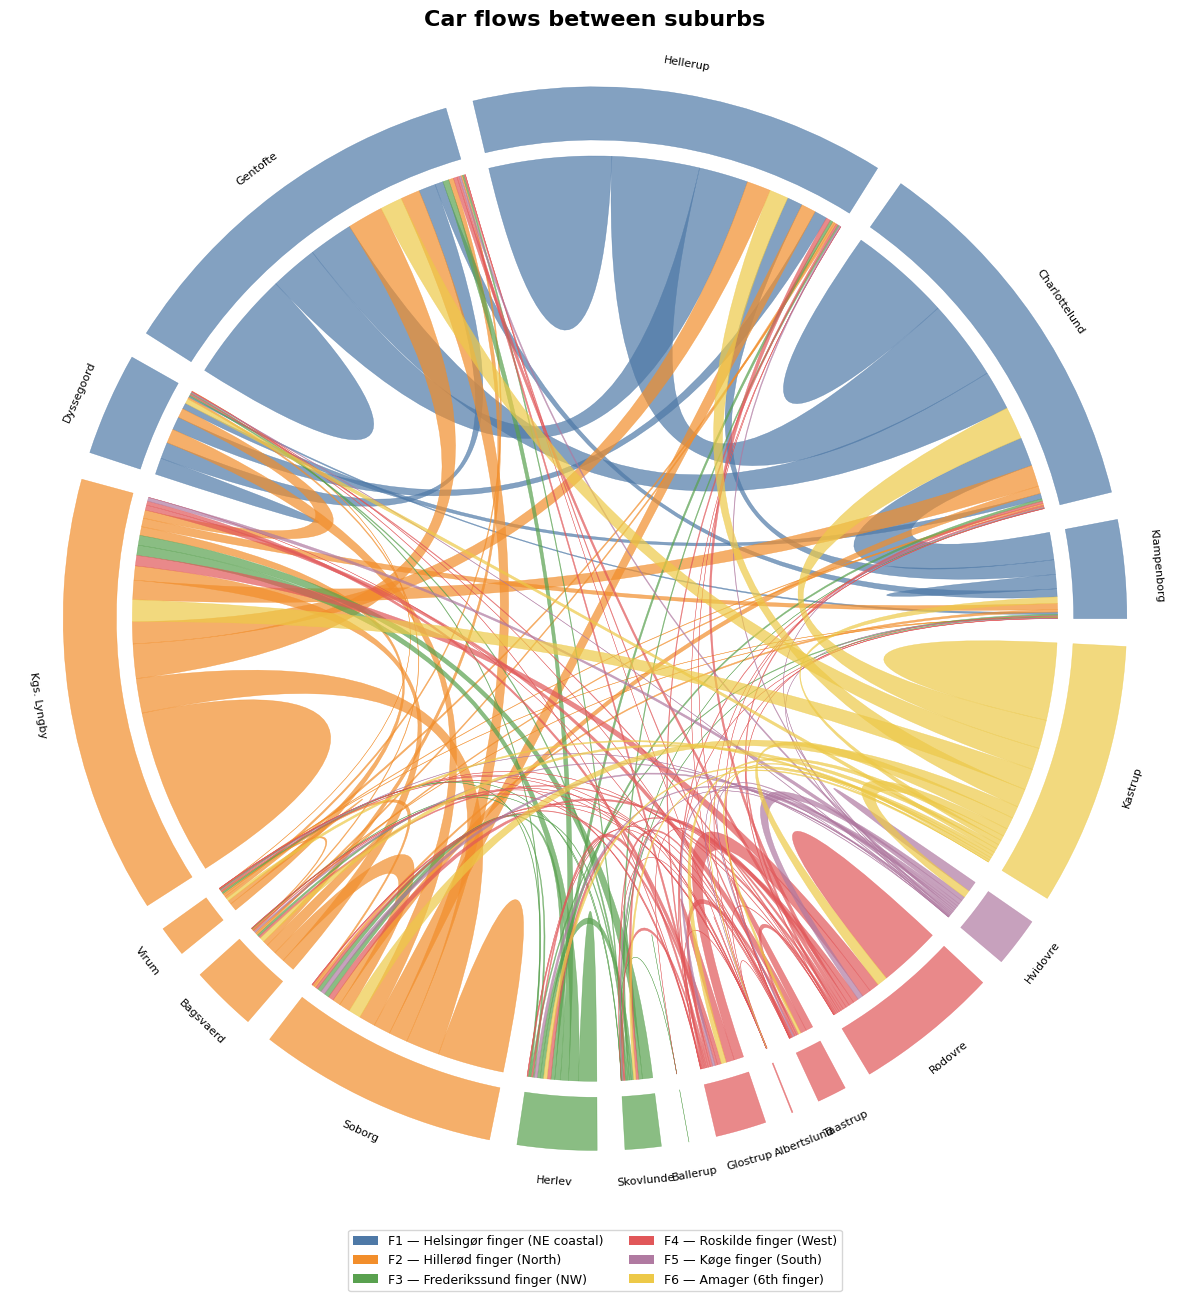

In [44]:
# Chore diagram
fig, ax = plt.subplots(figsize=(12, 12))
chord_diagram(matrix_no_cph, suburban_areas, ax=ax, fontsize=8, pad=3, colors=colors_suburban, rotate=20)
ax.legend(handles=legend_elements_suburban, loc='lower center',
          bbox_to_anchor=(0.5, -0.08), fontsize=9, framealpha=0.8, ncol=2)
plt.title('Car flows between suburbs', fontsize=16, fontweight='bold')
plt.savefig("../artifacts/chord_suburbs.png", dpi=150, bbox_inches='tight')
plt.show()

### Directional plots

In [31]:
flows_fingers_dir = (
    df.groupby(['finger_start', 'finger_end'])
    .size()
    .reset_index(name='flow')
)

In [32]:
finger_order = [
    'Copenhagen',
    'F1 Helsingør',
    'F2 Hillerød',
    'F3 Frederikssund',
    'F4 Roskilde',
    'F5 Køge',
    'F6 Amager',
]

label_map = {
    'Copenhagen':       'Copenhagen',
    'F1 Helsingør':     'F1\n(Helsingør)',
    'F2 Hillerød':      'F2\n(Hillerød)',
    'F3 Frederikssund': 'F3\n(Frederikssund)',
    'F4 Roskilde':      'F4\n(Roskilde)',
    'F5 Køge':          'F5\n(Køge)',
    'F6 Amager':        'F6\n(Amager)',
}

In [33]:
# Pivot to matrix

pivot = (
    flows_fingers_dir
    .pivot(index='finger_start', columns='finger_end', values='flow')
    .reindex(index=finger_order, columns=finger_order)
    .fillna(0)
    .astype(int)
)

pivot.index   = [label_map[i] for i in pivot.index]
pivot.columns = [label_map[c] for c in pivot.columns]

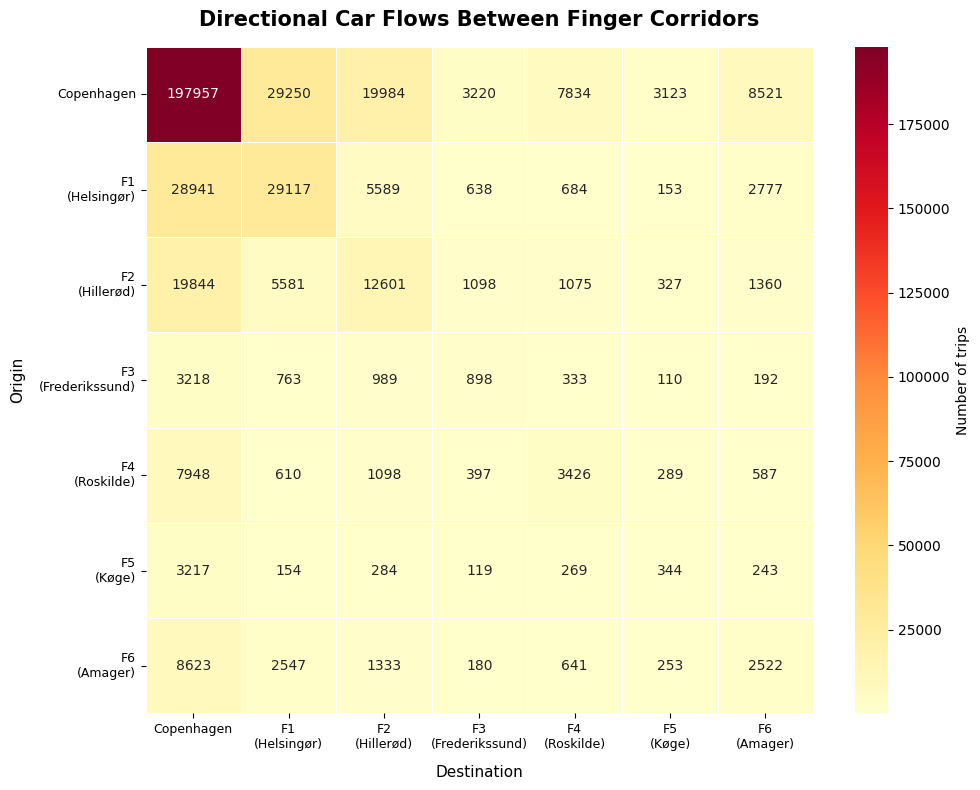

In [34]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    pivot,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Number of trips'},
)

ax.set_title('Directional Car Flows Between Finger Corridors',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Destination', fontsize=11, labelpad=10)
ax.set_ylabel('Origin', fontsize=11, labelpad=10)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9, rotation=0)

plt.tight_layout()
plt.savefig("../artifacts/heatmap_fingers.png", dpi=150, bbox_inches='tight')
plt.show()


## Normalize by population

In [35]:
# Load population - Statistiks Denmark https://www.statistikbanken.dk/statbank5a/default.asp?w=1440

pop_df = pd.read_csv('../data/population_municipalities.csv', encoding='latin-1', skiprows=2)
pop_df.columns = ['municipality', 'population']
pop_df = pop_df.dropna(subset=['population'])
pop_df['population'] = pop_df['population'].astype(int)
print(pop_df.head(4))


    municipality  population
0     Copenhagen      667099
1  Frederiksberg      105840
2         Dragør       14450
3         Tårnby       44034


In [36]:
# Map area-name to official municipality name
area_to_municipality = {
    'Kobenhavn K':     'Copenhagen',
    'Kobenhavn N':     'Copenhagen',
    'Kobenhavn NV':    'Copenhagen',
    'Kobenhavn O':     'Copenhagen',
    'Kobenhavn S':     'Copenhagen',
    'Kobenhavn SV':    'Copenhagen',
    'Kobenhavn V':     'Copenhagen',
    'Nordhavn':        'Copenhagen',
    'Bronshoj':        'Copenhagen',
    'Vanlose':         'Copenhagen',
    'Valby':           'Copenhagen',
    'Frederiksberg C': 'Frederiksberg',
    'Klampenborg':   'Gentofte',
    'Charlottelund': 'Gentofte',
    'Hellerup':      'Gentofte',
    'Gentofte':      'Gentofte',
    'Dyssegoord':    'Gentofte',
    'Kgs. Lyngby':   'Lyngby-Taarbæk',
    'Virum':         'Lyngby-Taarbæk',
    'Bagsvaerd':     'Gladsaxe',
    'Soborg':        'Gladsaxe',
    'Herlev':        'Herlev',
    'Skovlunde':     'Ballerup',
    'Ballerup':      'Ballerup',
    'Glostrup':      'Glostrup',
    'Albertslund':   'Albertslund',
    'Taastrup':      'Høje-Taastrup',
    'Rodovre':       'Rødovre',
    'Hvidovre':      'Hvidovre',
    'Kastrup':       'Tårnby',
}

In [37]:
pop_lookup = pop_df.set_index('municipality')['population'].to_dict()

# area_population = {
#     area: pop_lookup.get(muni, 0)
#     for area, muni in area_to_municipality.items()
# }
# print("Area populations:", area_population)

In [38]:
# Map finger group to population

finger_population = {
    'Copenhagen':           pop_lookup.get('Copenhagen', 0) + pop_lookup.get('Frederiksberg', 0),
    'F1 Helsingør':         pop_lookup.get('Gentofte', 0),
    'F2 Hillerød':          pop_lookup.get('Lyngby-Taarbæk', 0) + pop_lookup.get('Gladsaxe', 0),
    'F3 Frederikssund':     pop_lookup.get('Herlev', 0) + pop_lookup.get('Ballerup', 0),
    'F4 Roskilde':          (pop_lookup.get('Glostrup', 0) + pop_lookup.get('Albertslund', 0) +
                             pop_lookup.get('Høje-Taastrup', 0) + pop_lookup.get('Rødovre', 0)),
    'F5 Køge':              pop_lookup.get('Hvidovre', 0),
    'F6 Amager':            pop_lookup.get('Tårnby', 0),
}

print("Finger populations:", finger_population)

Finger populations: {'Copenhagen': 772939, 'F1 Helsingør': 75076, 'F2 Hillerød': 129671, 'F3 Frederikssund': 83723, 'F4 Roskilde': 156779, 'F5 Køge': 53760, 'F6 Amager': 44034}


#### Normalized heatmap

In [39]:
flows_fingers_dir['pop_origin']      = flows_fingers_dir['finger_start'].map(finger_population)
flows_fingers_dir['pop_destination'] = flows_fingers_dir['finger_end'].map(finger_population)
flows_fingers_dir['pop_combined']    = flows_fingers_dir['pop_origin'] + flows_fingers_dir['pop_destination']
flows_fingers_dir['flow_normalized'] = (
    flows_fingers_dir['flow'] / flows_fingers_dir['pop_combined'] * 100_000
).round(1)

In [40]:
pivot_norm = (
    flows_fingers_dir
    .pivot(index='finger_start', columns='finger_end', values='flow_normalized')
    .reindex(index=finger_order, columns=finger_order)
    .fillna(0)
)

pivot_norm.index   = [label_map[i] for i in pivot_norm.index]
pivot_norm.columns = [label_map[c] for c in pivot_norm.columns]

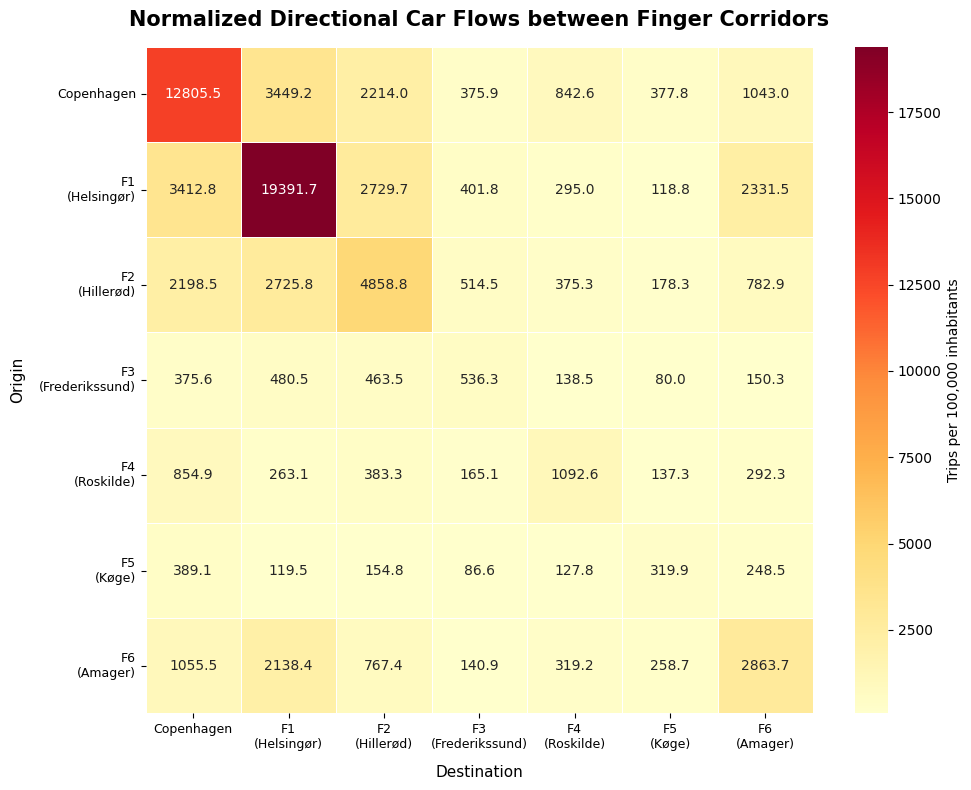

In [41]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    pivot_norm,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Trips per 100,000 inhabitants'},
)

ax.set_title('Normalized Directional Car Flows between Finger Corridors',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Destination', fontsize=11, labelpad=10)
ax.set_ylabel('Origin', fontsize=11, labelpad=10)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9, rotation=0)

plt.tight_layout()
plt.savefig("../artifacts/heatmap_fingers_normalized.png", dpi=150, bbox_inches='tight')
plt.show()